# Profiling Struphy with scope-profiler

This tutorial shows two ways to use `scope-profiler`:

1. Profile a small standalone Python workload with `ProfileManager` region timing.
2. Configure a Struphy `Simulation` with `ProfilingOptions`, including line profiling, and activate profiling at `sim.run(...)`.

The same HDF5 output file can be inspected from Python, from the command-line interface, or in the terminal TUI.

## Imports and output directory

Use a small temporary directory so repeated notebook runs do not overwrite production simulation data.

In [1]:
from pathlib import Path
import shutil
import tempfile

import numpy as np
from scope_profiler import ProfileManager

workdir = Path(tempfile.mkdtemp(prefix="struphy_profile_tutorial_"))


In [2]:
from contextlib import redirect_stderr, redirect_stdout
from html import escape
from io import StringIO

from IPython.display import HTML, display


def show_full_text(text: str):
    """Render long text as HTML so notebook frontends do not truncate stream output."""
    display(
        HTML(
            '<pre style="white-space: pre-wrap; overflow: visible; max-height: none; '
            'font-family: var(--jp-code-font-family, monospace);">'
            f"{escape(text)}"
            "</pre>"
        )
    )


def capture_full_output(func, *args, **kwargs):
    stdout = StringIO()
    stderr = StringIO()
    with redirect_stdout(stdout), redirect_stderr(stderr):
        result = func(*args, **kwargs)
    text = stderr.getvalue() + stdout.getvalue()
    if text:
        show_full_text(text)
    return result


## 1. Profile standalone Python code

`ProfileManager.profile_region(...)` profiles a `with` block. `@ProfileManager.profile(...)` profiles a decorated function. This first example only records region timings, which is enough for coarse timing and produces a small HDF5 profile file.

In [3]:
@ProfileManager.profile("demo: matrix multiply")
def matrix_work(n: int) -> float:
    a = np.arange(n * n, dtype=float).reshape(n, n)
    b = a.T.copy()
    c = a @ b
    return float(c.sum())


profile_file = workdir / "demo_scope_profile.h5"

with ProfileManager.session(
    file_path=str(profile_file),
    return_results=True,
    verbose=False,
) as prof:
    with ProfileManager.profile_region("demo: total"):
        total = 0.0
        for n in (16, 24, 32):
            total += matrix_work(n)
        print(f"Total sum: {total:.2f}")

results = prof.results

Total sum: 9785934080.00


The context manager finalizes the run and writes one HDF5 file. With `return_results=True`, the finalized result object is also available in memory.

In [4]:
results.print_summary(title="Standalone demo", include=[r"^demo:"])

  ╭──────────────────────────┬─────┬─────────────┬───────────╮
  │ region                   │ n   │ total [s]   │ avg [s]   │
  ├──────────────────────────┼─────┼─────────────┼───────────┤
  │ demo: total              │ 1   │ 4.4e-04     │ 4.4e-04   │
  │ └─ demo: matrix multiply │ 3   │ 2.3e-04     │ 7.7e-05   │
  │ TOTAL                    │ 4   │ 6.7e-04     │           │
  ╰──────────────────────────┴─────┴─────────────┴───────────╯

  ╭─ Info ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
  │ Summary: Standalone demo                                                                                                                   │
  │                                                                                                                                            │
  │ Explore:                                                                                                               

The same file can be inspected from Python. The CLI and TUI commands are shown later for terminal workflows.


In [5]:
from scope_profiler import read_h5

standalone_results = read_h5(profile_file)
standalone_results.print_summary(title="Standalone HDF5 summary", include=[r"^demo:"])


  ╭──────────────────────────┬─────┬─────────────┬───────────╮
  │ region                   │ n   │ total [s]   │ avg [s]   │
  ├──────────────────────────┼─────┼─────────────┼───────────┤
  │ demo: total              │ 1   │ 4.4e-04     │ 4.4e-04   │
  │ └─ demo: matrix multiply │ 3   │ 2.3e-04     │ 7.7e-05   │
  │ TOTAL                    │ 4   │ 6.7e-04     │           │
  ╰──────────────────────────┴─────┴─────────────┴───────────╯

  ╭─ Info ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
  │ Summary: Standalone HDF5 summary                                                                                                           │
  │                                                                                                                                            │
  │ Explore:                                                                                                               

## 2. Profile a Struphy simulation

Struphy instruments the important phases of `Simulation.run()` with `ProfileManager`: allocation and setup, the time-stepping loop (`model.integrate`), propagators and solvers, diagnostics, particle sorting, and output. A profiling session is only active when `sim.run(profiling_activated=True)` is called. This means the same `Simulation` setup can be used for an ordinary run or a measured run.

For a useful performance experiment, keep the problem small enough to run quickly but make the time-stepping loop execute several times. Include a warm-up run when comparing configurations: compilation, cache creation, allocation, and filesystem setup can otherwise dominate the measurement. Use `save_step` to avoid measuring a workload dominated by output. Start with region timing; enable `use_line_profiler=True` only after the expensive region is known, because line profiling adds substantial overhead.

In [6]:
from struphy import EnvironmentOptions, ProfilingOptions, Simulation, Time, grids
from struphy.models import Poisson

env = EnvironmentOptions(
    out_folders=str(workdir),
    sim_folder="poisson_profile_demo",
    # Saving every step is useful for a demo, but can dominate a benchmark.
    save_step=1,
)

profiling_opts = ProfilingOptions(
    file_path=str(workdir / "poisson_profile.h5"),
    # First locate the expensive region with region timing.
    use_line_profiler=False,
)

sim = Simulation(
    model=Poisson(),
    env=env,
    time_opts=Time(dt=0.01, Tend=0.01),
    grid=grids.TensorProductGrid(num_elements=(4, 4, 1)),
    profiling_opts=profiling_opts,
)

In [7]:
# This profiles the complete Simulation.run() call, including setup,
# model.integrate(), diagnostics, and data output.
sim.run(profiling_activated=True)
struphy_profile_file = Path(profiling_opts.file_path)


Stabilizing Poisson solve with self.options.sigma_1 =1e-14


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 137.39step/s]


  ╭──────────────────────────────────────┬─────┬─────────────┬─────────────┬───────────╮
  │ region                               │ n   │ % session   │ total [s]   │ avg [s]   │
  ├──────────────────────────────────────┼─────┼─────────────┼─────────────┼───────────┤
  │ scope_profiler.session               │ 1   │ 100.00%     │ 2.3e-01     │ 2.3e-01   │
  │ └─ setup: total                      │ 1   │ 94.97%      │ 2.2e-01     │ 2.2e-01   │
  │ │ └─ setup: allocate                 │ 1   │ 73.81%      │ 1.7e-01     │ 1.7e-01   │
  │ │ │ └─ setup: feec                   │ 1   │ 67.60%      │ 1.5e-01     │ 1.5e-01   │
  │ │ │ │ └─ setup: derham               │ 1   │ 67.21%      │ 1.5e-01     │ 1.5e-01   │
  │ │ │ │ └─ setup: mass ops             │ 1   │ 0.03%       │ 6.4e-05     │ 6.4e-05   │
  │ │ │ │ └─ setup: basis ops            │ 1   │ 0.32%       │ 7.3e-04     │ 7.3e-04   │
  │ │ │ └─ setup: variables              │ 1   │ 0.92%       │ 2.1e-03     │ 2.1e-03   │
  │ │ │ │ └─ setup v

In [8]:
from scope_profiler import read_h5

profile_results = read_h5(struphy_profile_file)
region_names = sorted(region.name for region in profile_results.get_regions())
print(", ".join(region_names))

diagnostics, model.integrate, prop: PoissonSolve, save data, scope_profiler.session, setup prop: PoissonSolve, setup var: em_fields.phi, setup var: em_fields.source, setup: allocate, setup: basis ops, setup: data storage, setup: derham, setup: feec, setup: geometry vtk, setup: hdf5 datasets, setup: helpers, setup: initial diagnostics, setup: mass ops, setup: plasma params, setup: propagators, setup: run metadata, setup: total, setup: variables, solve: PoissonSolve, update_feec_variables


### Measure setup and time stepping separately

The profile contains both one-time setup and repeated work. For a performance experiment, inspect them separately: setup is useful for allocation and initialization studies, while `model.integrate` and its children describe the cost per time step. For a longer benchmark, increase `Tend` so several steps are recorded, and set `save_step` larger when output is not part of the question. Include a warm-up run before comparing configurations because compilation, cache creation, allocation, and filesystem setup can otherwise dominate the measurement.

In [9]:
capture_full_output(
    profile_results.print_summary,
    title="What did Simulation.run() measure?",
    include=[r"^setup:", r"^model\.integrate$", r"^prop: ", r"^solve:", r"^kernel: ", r"^save data$"],
)

### Line-profile output for selected Struphy regions

To get line-by-line timing, repeat the run with `use_line_profiler=True` (and preferably a shorter `Tend`). The HDF5 file then contains line-profile records for decorated functions and profiled regions. The filter below prints a representative solver region:

- `setup: total`, the top-level setup block in `Simulation.run`.
- `solve: PoissonSolve`, the Poisson propagator solve call.

The source column is shown because these regions come from real Struphy source files.

In [10]:
line_profile_opts = ProfilingOptions(
    file_path=str(workdir / "poisson_line_profile.h5"),
    use_line_profiler=True,
)
line_sim = Simulation(
    model=Poisson(),
    env=EnvironmentOptions(out_folders=str(workdir), sim_folder="poisson_line_demo", save_step=1),
    time_opts=Time(dt=0.01, Tend=0.01),
    grid=grids.TensorProductGrid(num_elements=(4, 4, 1)),
    profiling_opts=line_profile_opts,
)
line_sim.run(profiling_activated=True)
line_profile_file = Path(line_profile_opts.file_path)

Stabilizing Poisson solve with self.options.sigma_1 =1e-14


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 76.44step/s]


  ╭──────────────────────────────────────┬─────┬─────────────┬─────────────┬───────────╮
  │ region                               │ n   │ % session   │ total [s]   │ avg [s]   │
  ├──────────────────────────────────────┼─────┼─────────────┼─────────────┼───────────┤
  │ scope_profiler.session               │ 1   │ 100.00%     │ 3.1e-01     │ 3.1e-01   │
  │ └─ setup: total                      │ 1   │ 93.68%      │ 2.9e-01     │ 2.9e-01   │
  │ │ └─ setup: allocate                 │ 1   │ 59.26%      │ 1.8e-01     │ 1.8e-01   │
  │ │ │ └─ setup: feec                   │ 1   │ 50.17%      │ 1.5e-01     │ 1.5e-01   │
  │ │ │ │ └─ setup: derham               │ 1   │ 49.35%      │ 1.5e-01     │ 1.5e-01   │
  │ │ │ │ └─ setup: mass ops             │ 1   │ 0.04%       │ 1.2e-04     │ 1.2e-04   │
  │ │ │ │ └─ setup: basis ops            │ 1   │ 0.40%       │ 1.2e-03     │ 1.2e-03   │
  │ │ │ └─ setup: variables              │ 1   │ 0.72%       │ 2.2e-03     │ 2.2e-03   │
  │ │ │ │ └─ setup v

In [11]:
from scope_profiler.line_profile_cli import print_line_profile

print_line_profile(
    line_profile_file,
    region=r"^prop: PoissonSolve",
    display_html=True,
)

For a parameter file generated by `struphy params <ModelName>`, the same pattern is:

```python
profiling_opts = ProfilingOptions(
    file_path="my_profile.h5",
    use_line_profiler=True,
)

sim = Simulation(..., profiling_opts=profiling_opts)
sim.run(profiling_activated=True)
```

Omit the `profiling_activated` keyword for normal production runs without profiling overhead.

## 3. Plot and inspect the profile

There are three useful levels of inspection: the summary table finds expensive regions; the duration chart ranks them; and the Gantt/flame views explain when they run and how parent/child time is composed. A region's *inclusive* duration includes its children, so do not add the `model.integrate`, propagator, solver, and kernel bars together unless you intentionally want overlapping costs.

`scope-profiler` also provides a CLI and a terminal TUI for interactive work outside the notebook:

```bash
scope-profiler inspect profiling_data.h5
scope-profiler line-profile profiling_data.h5
scope-profiler plot durations profiling_data.h5 -o figures --sort-by total --top-n 20
scope-profiler plot durations profiling_data.h5 -o figures --stack-children --sort-by total --top-n 12
scope-profiler plot gantt profiling_data.h5 -o figures --min-duration 0.0001 --collapse-depth 4
scope-profiler plot flame_graph profiling_data.h5 -o figures
scope-profiler plot flame_chart profiling_data.h5 -o figures
scope-profiler plot quick profiling_data.h5 -o figures
scope-profiler tui profiling_data.h5
```

We recommend checking out the [scope-profiler documentation](https://max-models.github.io/scope-profiler/) for details on postprocessing using the tool.

The `--stack-children` option splits each duration bar into self time plus direct children. Use `--collapse-depth` and `--min-duration` to make a busy Gantt chart readable. `flame_graph` aggregates call stacks; `flame_chart` preserves their time position.

### IPython magics

The magics are useful for quick notebook experiments and comparisons. `%%scope` records a notebook cell as one named region; `%scope_load` imports the HDF5 profile produced by `sim.run()` into the same in-memory registry. Use the Struphy HDF5 profile for detailed nested run data, and magics for small local measurements or before/after comparisons.

In [12]:
%load_ext scope_profiler.ipython_magics

333283335000

%%scope 'notebook_overhead'
  ╭────────────────────────┬─────┬─────────────┬─────────────┬───────────╮
  │ region                 │ n   │ % session   │ total [s]   │ avg [s]   │
  ├────────────────────────┼─────┼─────────────┼─────────────┼───────────┤
  │ scope_profiler.session │ 1   │ 100.00%     │ 1.9e-03     │ 1.9e-03   │
  │ └─ notebook_overhead   │ 1   │ 99.38%      │ 1.9e-03     │ 1.9e-03   │
  │ TOTAL                  │ 2   │ 100.00%     │ 3.9e-03     │           │
  ╰────────────────────────┴─────┴─────────────┴─────────────┴───────────╯



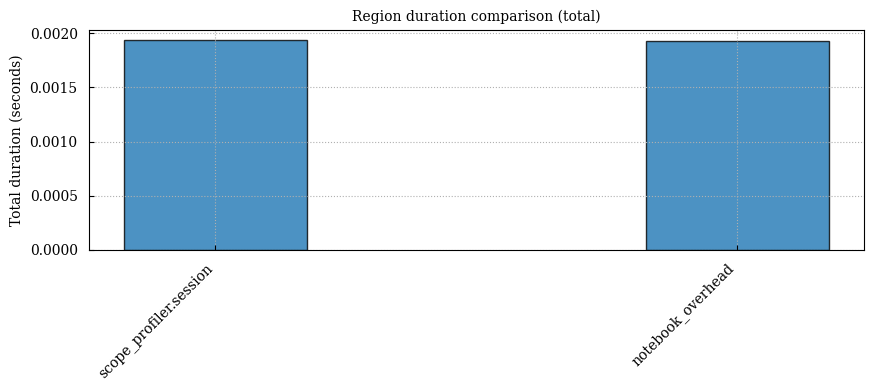

In [13]:
%%scope notebook_overhead -p
sum(i * i for i in range(10_000))


'struphy_run' (last)
  ╭───────────────────────────────┬─────┬─────────────┬───────────╮
  │ region                        │ n   │ total [s]   │ avg [s]   │
  ├───────────────────────────────┼─────┼─────────────┼───────────┤
  │ setup: total                  │ 1   │ 2.2e-01     │ 2.2e-01   │
  │ └─ setup: allocate            │ 1   │ 1.7e-01     │ 1.7e-01   │
  │ │ └─ setup: feec              │ 1   │ 1.5e-01     │ 1.5e-01   │
  │ │ │ └─ setup: derham          │ 1   │ 1.5e-01     │ 1.5e-01   │
  │ │ │ └─ setup: mass ops        │ 1   │ 6.4e-05     │ 6.4e-05   │
  │ │ │ └─ setup: basis ops       │ 1   │ 7.3e-04     │ 7.3e-04   │
  │ │ └─ setup: variables         │ 1   │ 2.1e-03     │ 2.1e-03   │
  │ │ └─ setup: propagators       │ 1   │ 8.8e-03     │ 8.8e-03   │
  │ │ └─ setup: helpers           │ 1   │ 3.2e-03     │ 3.2e-03   │
  │ └─ setup: run metadata        │ 1   │ 2.8e-04     │ 2.8e-04   │
  │ └─ setup: data storage        │ 1   │ 6.1e-03     │ 6.1e-03   │
  │ └─ setup: geometry vtk 

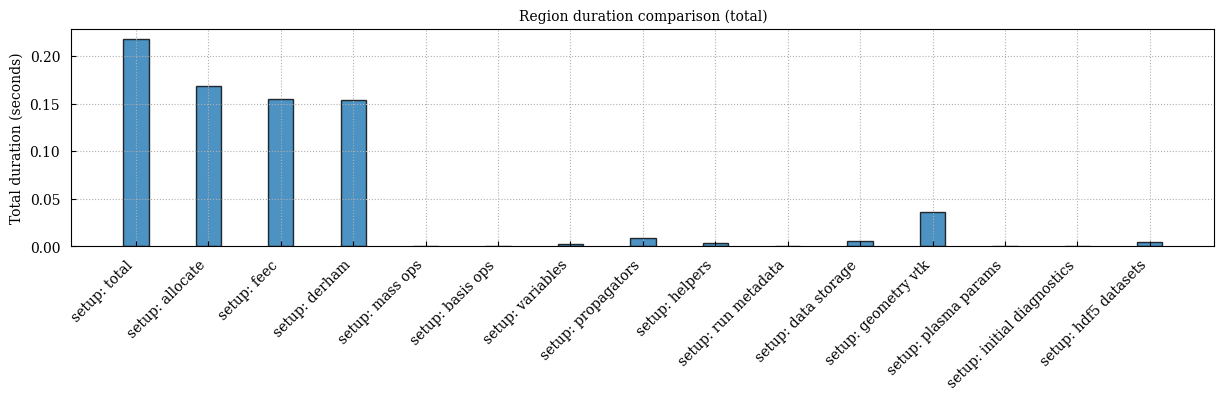

In [14]:
%scope_load {struphy_profile_file} -n struphy_run -q
%scope_last struphy_run --include ^setup: -p

Other useful magics are `%%scope_line` for a short decorated function, `%%scope_recursive` for exploratory tracing when no regions exist, `%scope_df` for pandas analysis, `%scope_compare` for two notebook runs, and `%scope_export` for `.prof` or speedscope output. Recursive tracing is noisy and expensive, so use it to discover candidate functions rather than to measure production performance.

In [15]:
capture_full_output(
    profile_results.print_summary,
    title="Poisson profiling summary",
    include=[r"^setup:", r"^model\.integrate$", r"^prop: ", r"^solve:", r"^update_feec_variables$"],
)


In [16]:
from scope_profiler import plot_durations, plot_flame, plot_gantt

include_regions = [
    r"^setup:",
    r"^model\.integrate$",
    r"^prop: ",
    r"^solve:",
    r"^kernel: ",
    r"^update_feec_variables$",
]

Plotting duration comparison (total) for files: poisson_profile


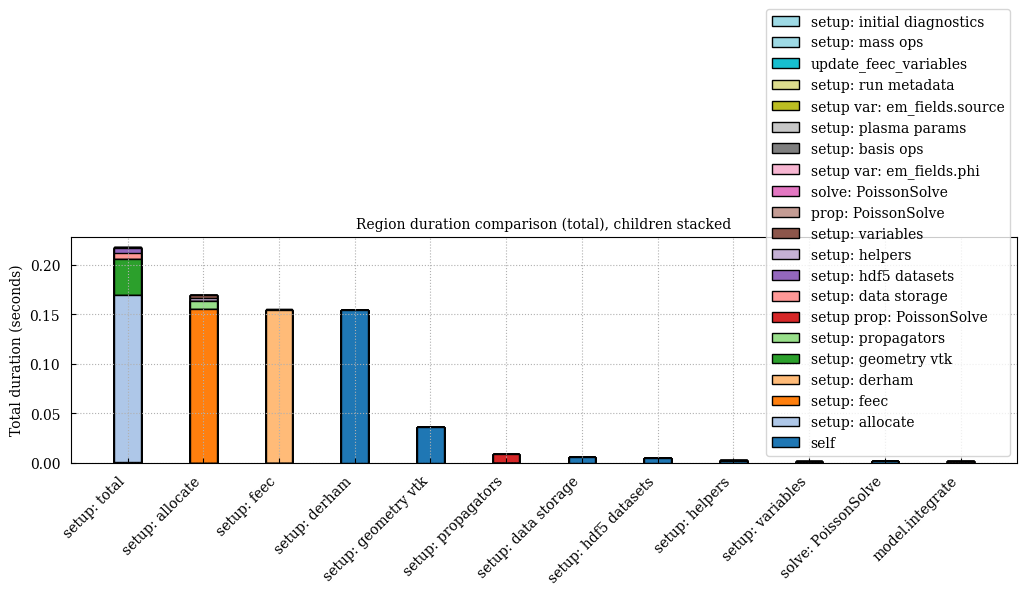

In [17]:

duration_figure, _ = plot_durations(
    profile_results,
    include=include_regions,
    sort_by="total",
    top_n=12,
    stack_children=True,
    filepath=str(workdir / "durations_with_children.png"),
    return_fig=True,
)



Plotting Gantt chart for ranks: [0]
Plotting flame chart for: poisson_profile (rank 0)
For interactive flame-chart hover details, use --backend plotly.


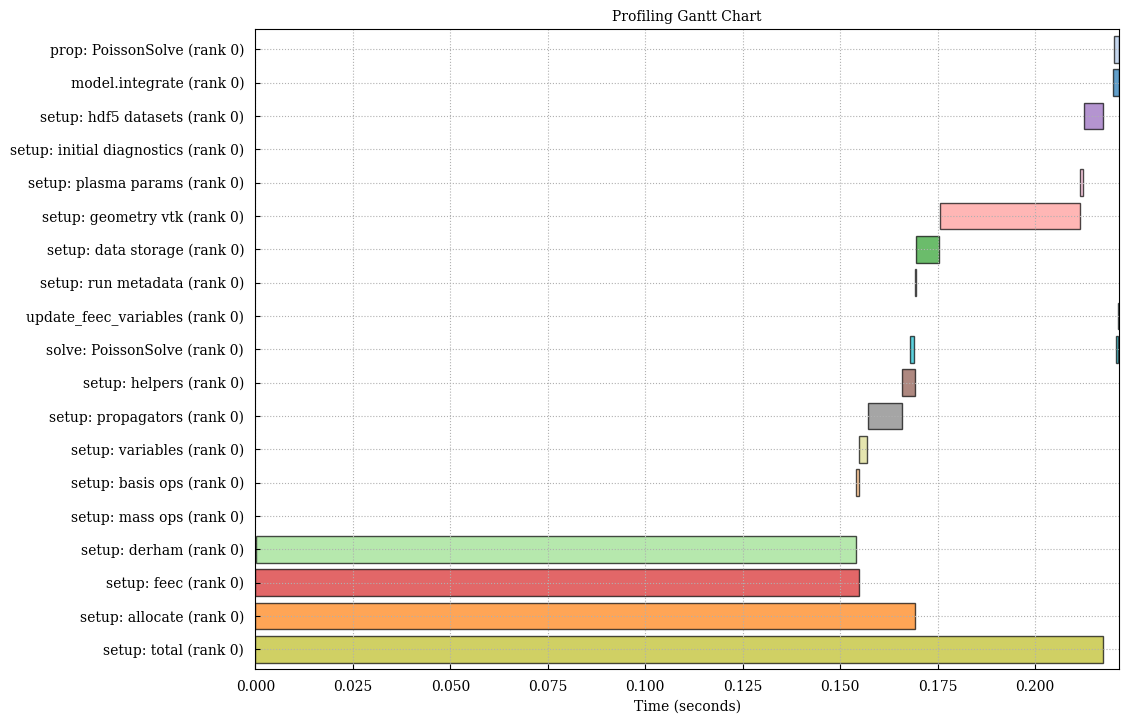

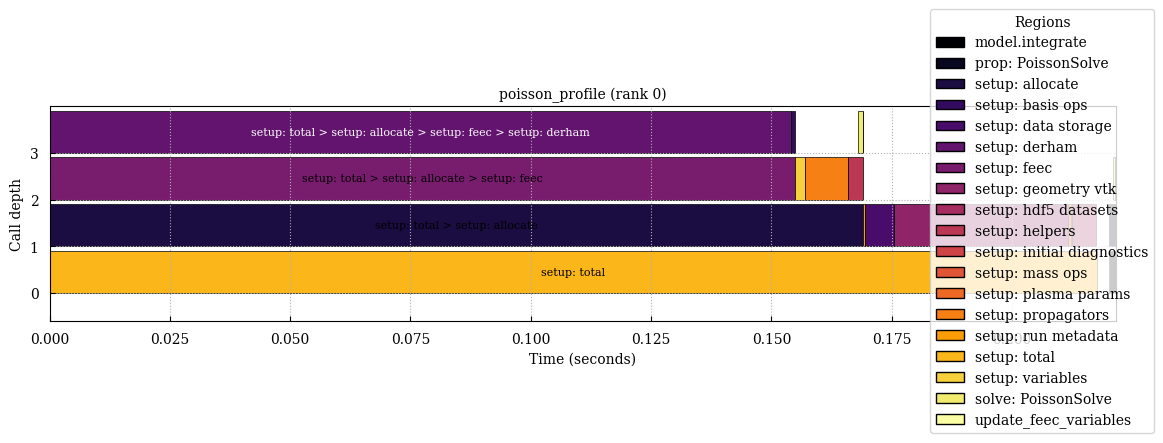

In [18]:
gantt_figure, _ = plot_gantt(
    profile_results,
    include=include_regions,
    min_duration=1e-4,
    collapse_depth=4,
    filepath=str(workdir / "gantt.png"),
    return_fig=True,
)

flame_figure = plot_flame(
    profile_results,
    include=include_regions,
    filepath=str(workdir / "flame_graph.png"),
    return_fig=True,
)

The duration chart ranks regions by aggregate time and stacks self time with direct children. The Gantt chart shows the execution timeline and can expose idle time, serialization, or rank imbalance. The flame graph reconstructs nested calls and is useful for reading parent/child relationships between `setup`, `model.integrate`, propagators, solvers, and kernels. The figures are also saved under `workdir`, so the same workflow works in a headless batch job.

## Cleanup

Remove the temporary directory when you no longer need the profiling files.

In [19]:
# shutil.rmtree(workdir)